In [18]:
import numpy as np
import matplotlib.pyplot as plt


def plot_ion_tracks_3d(
    geometry,
    events,
    srim,
    max_events=100,
    z_view_above_surface=10e-9,
    figsize=(8, 8),
):
    """
    3D visualization of ions intersecting the sample surface.

    Shows:
      - sample top surface only
      - ion tracks near surface
      - SRIM stopping endpoints

    Camera/view is zoomed near the surface
    (default: 10 nm above top surface).

    Assumes straight-line SRIM projected range.
    """

    # ========================================================
    # SETUP FIGURE
    # ========================================================

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")

    # ========================================================
    # GEOMETRY BOUNDS
    # ========================================================

    x0, y0, z0 = geometry.location

    xmin = x0 - geometry.hx
    xmax = x0 + geometry.hx

    ymin = y0 - geometry.hy
    ymax = y0 + geometry.hy

    z_top = z0 + geometry.hz

    # ========================================================
    # DRAW TOP SURFACE ONLY
    # ========================================================

    Xs = np.array([
        [xmin, xmax],
        [xmin, xmax]
    ])

    Ys = np.array([
        [ymin, ymin],
        [ymax, ymax]
    ])

    Zs = np.full_like(Xs, z_top)

    ax.plot_surface(
        Xs,
        Ys,
        Zs,
        alpha=0.3
    )

    # ========================================================
    # PLOT TRACKS
    # ========================================================

    count = 0

    for e in events:

        if count >= max_events:
            break

        pos = np.array(e.pos)

        direction = e.vel / np.linalg.norm(e.vel)

        # only ions moving toward sample
        if direction[2] <= 0:
            continue

        # intersection with top surface
        dz = z_top - pos[2]

        if dz < 0:
            continue

        t_surface = dz / direction[2]

        impact = pos + t_surface * direction

        # must intersect inside xy bounds
        if not (
            xmin <= impact[0] <= xmax and
            ymin <= impact[1] <= ymax
        ):
            continue

        # projected SRIM stopping endpoint
        end = impact + srim.range * direction

        # ====================================================
        # PLOT TRACK
        # ====================================================

        ax.plot(
            [impact[0], end[0]],
            [impact[1], end[1]],
            [impact[2], end[2]],
            alpha=0.6
        )

        # impact point
        ax.scatter(
            impact[0],
            impact[1],
            impact[2],
            s=20
        )

        # stopping point
        ax.scatter(
            end[0],
            end[1],
            end[2],
            s=20
        )

        count += 1

    # ========================================================
    # VIEW SETTINGS
    # ========================================================

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # only show tiny region above surface
    ax.set_zlim(
        z_top - geometry.lz,
        z_top + z_view_above_surface
    )

    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_zlabel("z (m)")

    ax.set_title(
        f"{srim.ion_name} Tracks Into {geometry.material.name}"
    )

    plt.show()

In [36]:
from ion_source import AlphaEmitter,GaussianIonBeam
from geometry import Geometry
from material import Material
from srim_output import SRIMOutput

# ============================================================
# SRIM DATA
# ============================================================

he_srim = SRIMOutput(

    ion_name="He",
    ion_energy_eV=5.3e6,
    ion_mass_amu=4.003,

    dEdx_electronic=3.510e2 * 1.602e-10,
    dEdx_nuclear=2.727e-1 * 1.602e-10,

    range_projected=10.18e-6,
    straggle_long=4503e-10,
    straggle_trans=5510e-10,
)

# ============================================================
# MATERIAL
# ============================================================

nbn = Material(
    name="NbN",
    srim=he_srim
)

# ============================================================
# GEOMETRY
# ============================================================

geom = Geometry(
    location=(0, 0, 0),
    lx=20e-6,
    ly=20e-6,
    lz=20e-6,
    material=nbn
)

# ============================================================
# ION SOURCE
# ============================================================

alpha = AlphaEmitter(
    activity_Bq=1e5,
    position=(0, 0, 0)
)

alpha_events = alpha.sample(1e-3)

beam = GaussianIonBeam(
    current_A=1e-12,            # 1 pA beam
    energy_eV=2000,            # 2 keV ions
    mass_amu=40,               # e.g., Ar+
    sigma_x=1e-3,
    sigma_y=1e-3,
    angular_spread=0.02,
    origin=(0,0,0),
    direction=(0,0,-1)
)

beam_events = beam.sample(1e-3)




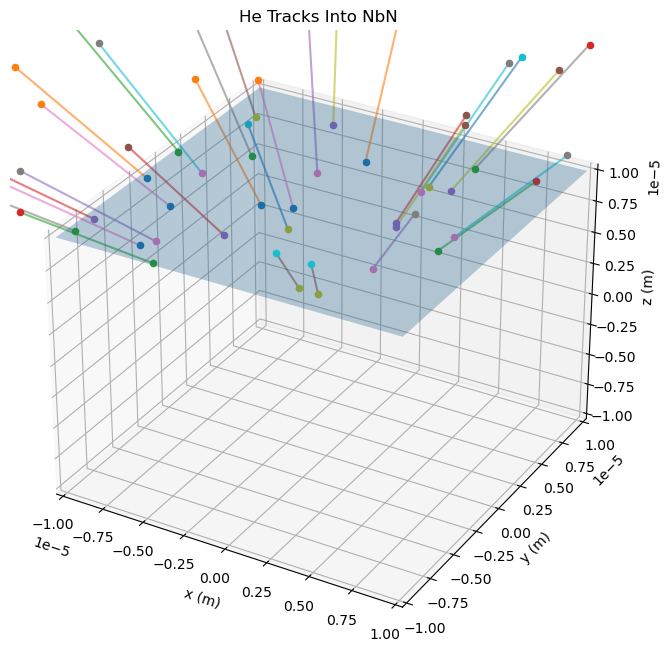

In [37]:
# ============================================================
# PLOT
# ============================================================

plot_ion_tracks_3d(
    geometry=geom,
    events=alpha_events,
    srim=he_srim,
    max_events=50000
)

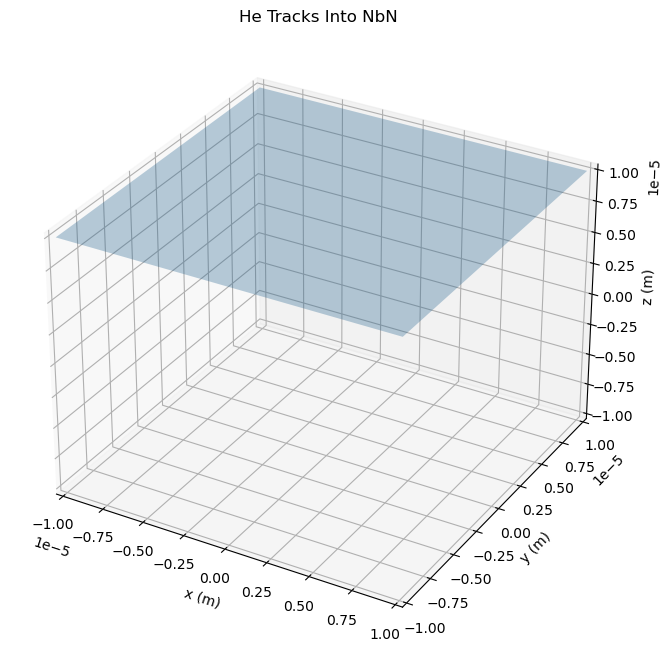

In [38]:
plot_ion_tracks_3d(
    geometry=geom,
    events=beam_events,
    srim=he_srim,
    max_events=50000
)